# Caso 1: SIMPLE - Calidad de Datos RENAMU 2022 (Registro Nacional de Municipalidades)

---

## Contexto del Proyecto

### Descripción del Problema
El **Instituto Nacional de Estadística e Informática (INEI)**, a través del
**RENAMU** (Registro Nacional de Municipalidades), recopila información
administrativa, de recursos humanos, servicios y gestión de las municipalidades
peruanas. Al consolidar los datos del año 2022, se detectan valores faltantes,
inconsistencias en códigos geográficos y registros duplicados que impiden
generar análisis confiables por municipalidad.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos del RENAMU 2022 para:
- Verificar la integridad del Ubigeo como clave de identificación
- Detectar registros duplicados por municipalidad
- Identificar valores faltantes en campos geográficos clave
- Preparar el dataset limpio para el JOIN con SIAF y SISMEPRE en Silver

### Impacto de la Mala Calidad de Datos
- **Financiero**: Un Ubigeo incorrecto rompe el JOIN con SIAF y SISMEPRE,
  perdiendo información presupuestal de municipalidades
- **Operativo**: Duplicados por municipalidad generan conteos incorrectos
  de servicios y personal municipal
- **Estratégico**: Decisiones de política pública basadas en datos
  incompletos afectan la asignación de recursos a municipios

---

## Dimensiones de Calidad a Evaluar

1. **Completitud**: ¿Todos los registros tienen Ubigeo, Departamento,
   Provincia y Distrito completos?
2. **Exactitud**: ¿El Ubigeo tiene 6 dígitos y es coherente con los
   códigos ccdd, ccpp, ccdi?
3. **Consistencia**: ¿Los campos ccdd, ccpp, ccdi son coherentes
   con el Ubigeo registrado?
4. **Integridad**: ¿El código ccdd está en el rango válido (01-25)?
5. **Razonabilidad**: ¿El Tipomuni tiene solo valores permitidos (1-5)?
6. **Oportunidad**: ¿Todos los registros corresponden al año 2022?
7. **Unicidad**: ¿Existen municipalidades duplicadas por Ubigeo?
8. **Validez**: ¿El Ubigeo tiene exactamente 6 caracteres?

In [1]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## Carga de Data


In [2]:
# Cargar datos RENAMU 2022
df = pd.read_csv('Base_RENAMU_2022_f.csv', encoding='latin-1', sep=';')

print(f"✅ Dataset RENAMU 2022 cargado correctamente")

✅ Dataset RENAMU 2022 cargado correctamente


In [3]:
# Vista previa del dataset
df.head(10)

,ï»¿AÃ±o,idmunici,ccdd,ccpp,ccdi,Ubigeo,Departamento,Provincia,Distrito,Tipomuni,...,C97_2_2_3_6,C97_2_2_3_7,C97_2_2_3_8,C97_2_2_3_9,C97_2_2_3_10,C97_2_2_3_11,C97_2_2_4,C97_2_3,C97_2_4,C97_3
0,2022,10101,1,1,1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,1,...,"180839,86","4282884,66",0,0,"363709,19",0,"1215916,85",0,0,0
1,2022,10102,1,1,2,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,2,...,0,155045,0,0,79550,0,"58243,34",0,0,0
2,2022,10103,1,1,3,10103,AMAZONAS,CHACHAPOYAS,BALSAS,2,...,0,0,0,0,0,0,132800,0,0,0
3,2022,10104,1,1,4,10104,AMAZONAS,CHACHAPOYAS,CHETO,2,...,0,"187296,37",0,0,0,0,"133309,38",0,0,0
4,2022,10105,1,1,5,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,2,...,0,316713,0,0,0,0,73825,0,0,0
5,2022,10106,1,1,6,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,2,...,0,0,"85348,72",0,0,0,"474378,51",0,0,0
6,2022,10107,1,1,7,10107,AMAZONAS,CHACHAPOYAS,GRANADA,2,...,0,"365579,11",0,63037,0,0,75260,0,0,0
7,2022,10108,1,1,8,10108,AMAZONAS,CHACHAPOYAS,HUANCAS,2,...,0,"121356,2",0,0,"47209,71",0,41000,0,0,0
8,2022,10109,1,1,9,10109,AMAZONAS,CHACHAPOYAS,LA JALCA,2,...,0,"384534,15","276900,45",0,"406576,6",0,"139273,43",0,0,0
9,2022,10110,1,1,10,10110,AMAZONAS,CHACHAPOYAS,LEIMEBAMBA,2,...,0,"269907,8",0,14170,0,0,"489464,73",0,0,0


In [7]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Columns: 1368 entries, ï»¿AÃ±o to C97_3
dtypes: int64(539), object(9), str(820)
memory usage: 22.2+ MB


---

# FASE 1: Exploración Inicial y Diagnóstico de Calidad

Antes de limpiar datos, es fundamental **entender** qué problemas existen.
Esta es la fase de "Comprensión de Datos" de CRISP-DM aplicada al dataset
RENAMU 2022 de municipalidades peruanas.

## Análisis Descriptivo Básico

In [5]:
# Estadísticas descriptivas
df.describe()

,ï»¿AÃ±o,idmunici,ccdd,ccpp,ccdi,Ubigeo,Tipomuni,VFI,P04_1,P05_CC,...,P101_1,P101_2,P101_3,P101_4,P101_5,P101_6,VFI_P102,P102,VFI_C96,VFI_C97
count,1874.0,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000,1874.0,1874.000000,1874.000000,...,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000,1874.0,1874.000000,1874.0,1874.0
mean,2022.0,106811.441836,10.626467,5.394344,7.332978,106811.441836,1.895411,1.0,3.331377,55.229456,...,0.297759,0.657417,0.834045,1.094984,0.627001,1.831377,1.0,1.671291,1.0,1.0
std,0.0,67126.358611,6.720669,3.900907,6.475558,67126.358611,0.306105,0.0,1.963252,21.895658,...,0.457395,0.939738,1.344421,1.783997,1.656303,2.763765,0.0,0.469869,0.0,0.0
min,2022.0,10101.000000,1.000000,1.000000,1.000000,10101.000000,1.000000,1.0,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.0,1.0
25%,2022.0,50328.250000,5.000000,2.000000,3.000000,50328.250000,2.000000,1.0,2.000000,43.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,1.0,1.0
50%,2022.0,100322.500000,10.000000,5.000000,6.000000,100322.500000,2.000000,1.0,3.000000,62.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,2.000000,1.0,1.0
75%,2022.0,150805.750000,15.000000,8.000000,9.750000,150805.750000,2.000000,1.0,6.000000,67.000000,...,1.000000,2.000000,3.000000,4.000000,0.000000,6.000000,1.0,2.000000,1.0,1.0
max,2022.0,250401.000000,25.000000,20.000000,43.000000,250401.000000,2.000000,1.0,6.000000,84.000000,...,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,1.0,2.000000,1.0,1.0


### Interpretación Inicial

**Observaciones clave del dataset RENAMU 2022:**
- `Ubigeo` es la clave principal de cada municipalidad — debe tener
  exactamente 6 caracteres y no puede estar vacío
- `ccdd`, `ccpp`, `ccdi` deben ser coherentes con el Ubigeo registrado
- `Tipomuni` debe tener solo valores permitidos según el catálogo INEI
- `Año` debe ser 2022 para todos los registros

Estos son **indicadores claros** de problemas de calidad que guiarán
las correcciones en las siguientes fases.

## Diagnóstico por Dimensión de Calidad

In [8]:
# ============================================
# 1. COMPLETITUD
# ============================================
print("\nCOMPLETITUD - Análisis de Valores Faltantes")

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal de campos con datos faltantes: {len(missing_df)}")
else:
    print("No se encontraron valores faltantes")


COMPLETITUD - Análisis de Valores Faltantes
No se encontraron valores faltantes


In [12]:
# ============================================
# 2. EXACTITUD
# ============================================
print("\n\nEXACTITUD - Valores Incorrectos")

# Verificar el nombre real de la columna año
col_anio = [c for c in df.columns if 'o' in c.lower() or 'a' in c.lower()[:2]][0]
print(f"Columna año detectada: '{col_anio}'")

# Ubigeo con longitud diferente a 6
ubigeo_invalido = df[df['Ubigeo'].astype(str).str.len() != 6]
print(f"- Ubigeo con longitud diferente a 6: {len(ubigeo_invalido)}")

# Ubigeo que no coincide con ccdd+ccpp+ccdi
df['Ubigeo_calculado'] = (
    df['ccdd'].astype(str).str.zfill(2) +
    df['ccpp'].astype(str).str.zfill(2) +
    df['ccdi'].astype(str).str.zfill(2)
)
ubigeo_inconsistente = df[df['Ubigeo'].astype(str) != df['Ubigeo_calculado']]
print(f"- Ubigeo inconsistente con ccdd+ccpp+ccdi: {len(ubigeo_inconsistente)}")

# Año diferente a 2022
anio_invalido = df[df[col_anio] != 2022]
print(f"- Año diferente a 2022: {len(anio_invalido)}")



EXACTITUD - Valores Incorrectos
Columna año detectada: 'ï»¿AÃ±o'
- Ubigeo con longitud diferente a 6: 908
- Ubigeo inconsistente con ccdd+ccpp+ccdi: 908
- Año diferente a 2022: 0


In [10]:
# ============================================
# 3. CONSISTENCIA
# ============================================
print("\n\nCONSISTENCIA - Incoherencias entre Campos")

# Ubigeo vs ccdd+ccpp+ccdi
inconsistencias_ubigeo = df[df['Ubigeo'].astype(str) != df['Ubigeo_calculado']]
print(f"Ubigeo vs ccdd+ccpp+ccdi inconsistentes: {len(inconsistencias_ubigeo)}")

# Departamento duplicado con diferente ccdd
dpto_check = df.groupby('Departamento')['ccdd'].nunique()
inconsist_dpto = dpto_check[dpto_check > 1]
print(f"Departamentos con más de un código ccdd: {len(inconsist_dpto)}")

# Provincia duplicada con diferente ccpp
prov_check = df.groupby('Provincia')['ccpp'].nunique()
inconsist_prov = prov_check[prov_check > 1]
print(f"Provincias con más de un código ccpp: {len(inconsist_prov)}")



CONSISTENCIA - Incoherencias entre Campos
Ubigeo vs ccdd+ccpp+ccdi inconsistentes: 908
Departamentos con más de un código ccdd: 0
Provincias con más de un código ccpp: 0


In [11]:
# ============================================
# 4. INTEGRIDAD
# ============================================
print("\n\nINTEGRIDAD - Relaciones entre Datos")

# ccdd fuera de rango válido (01-25)
ccdd_invalido = df[(df['ccdd'] < 1) | (df['ccdd'] > 25)]
print(f"ccdd fuera de rango [01-25]: {len(ccdd_invalido)}")

# idmunici nulo o vacío
idmunici_invalido = df[df['idmunici'].isnull() | (df['idmunici'].astype(str).str.strip() == '')]
print(f"idmunici nulo o vacío: {len(idmunici_invalido)}")

# Ubigeo nulo
ubigeo_nulo = df[df['Ubigeo'].isnull()]
print(f"Ubigeo nulo: {len(ubigeo_nulo)}")



INTEGRIDAD - Relaciones entre Datos
ccdd fuera de rango [01-25]: 0
idmunici nulo o vacío: 0
Ubigeo nulo: 0


In [13]:
# ============================================
# 5. RAZONABILIDAD
# ============================================
print("\n\nRAZONABILIDAD - Valores Fuera de Rangos Esperados")

# Tipomuni fuera de rango válido (1-5)
tipomuni_invalido = df[(df['Tipomuni'] < 1) | (df['Tipomuni'] > 5)]
print(f"Tipomuni fuera de rango [1-5]: {len(tipomuni_invalido)}")

# ccdd fuera de rango extremo
ccdd_extremo = df[(df['ccdd'] < 1) | (df['ccdd'] > 25)]
print(f"ccdd fuera de rango extremo [01-25]: {len(ccdd_extremo)}")



RAZONABILIDAD - Valores Fuera de Rangos Esperados
Tipomuni fuera de rango [1-5]: 0
ccdd fuera de rango extremo [01-25]: 0


In [14]:
# ============================================
# 6. OPORTUNIDAD
# ============================================
print("\n\nOPORTUNIDAD - Actualidad de los Datos")

# Registros con año diferente a 2022
anio_fuera = df[df[col_anio] != 2022]
print(f"- Registros con año diferente a 2022: {len(anio_fuera)}")

# Distribución de años presentes
print(f"- Años distintos en el dataset: {df[col_anio].unique()}")



OPORTUNIDAD - Actualidad de los Datos
- Registros con año diferente a 2022: 0
- Años distintos en el dataset: [2022]


In [15]:
# ============================================
# 7. UNICIDAD
# ============================================
print("\n\nUNICIDAD - Duplicados")

# Duplicados exactos
cols_duplicados = [c for c in df.columns]
duplicados_exactos = df[df.duplicated(subset=cols_duplicados, keep=False)]
print(f"- Registros duplicados (exactos): {len(duplicados_exactos)}")

# Duplicados parciales por Ubigeo (una municipalidad no debería repetirse)
cols_key = ['Ubigeo']
duplicados_parciales = df[df.duplicated(subset=cols_key, keep=False)]
print(f"- Duplicados por Ubigeo: {len(duplicados_parciales)}")



UNICIDAD - Duplicados
- Registros duplicados (exactos): 0
- Duplicados por Ubigeo: 0


In [16]:
# ============================================
# 8. VALIDEZ
# ============================================
print("\n\nVALIDEZ - Formatos Incorrectos")

# Ubigeo debe tener exactamente 6 caracteres numéricos
ubigeo_formato_invalido = df[~df['Ubigeo'].astype(str).str.match(r'^\d{6}$')]
print(f"- Ubigeo con formato inválido (no 6 dígitos numéricos): {len(ubigeo_formato_invalido)}")

# Tipomuni debe ser entero entre 1 y 5
tipomuni_invalido_val = df[~df['Tipomuni'].isin([1, 2, 3, 4, 5])]
print(f"- Tipomuni con valor inválido (fuera de 1-5): {len(tipomuni_invalido_val)}")



VALIDEZ - Formatos Incorrectos
- Ubigeo con formato inválido (no 6 dígitos numéricos): 908
- Tipomuni con valor inválido (fuera de 1-5): 0


In [17]:
print("RESUMEN DEL DIAGNÓSTICO")
print(f"- Total de registros: {len(df)}")
print(f"- Total de problemas detectados: {len(missing_df) + len(ubigeo_invalido) + len(ubigeo_inconsistente) + len(ccdd_invalido) + len(duplicados_exactos) + len(ubigeo_formato_invalido)}")

RESUMEN DEL DIAGNÓSTICO
- Total de registros: 1874
- Total de problemas detectados: 2724


## Visualización de Problemas de Calidad

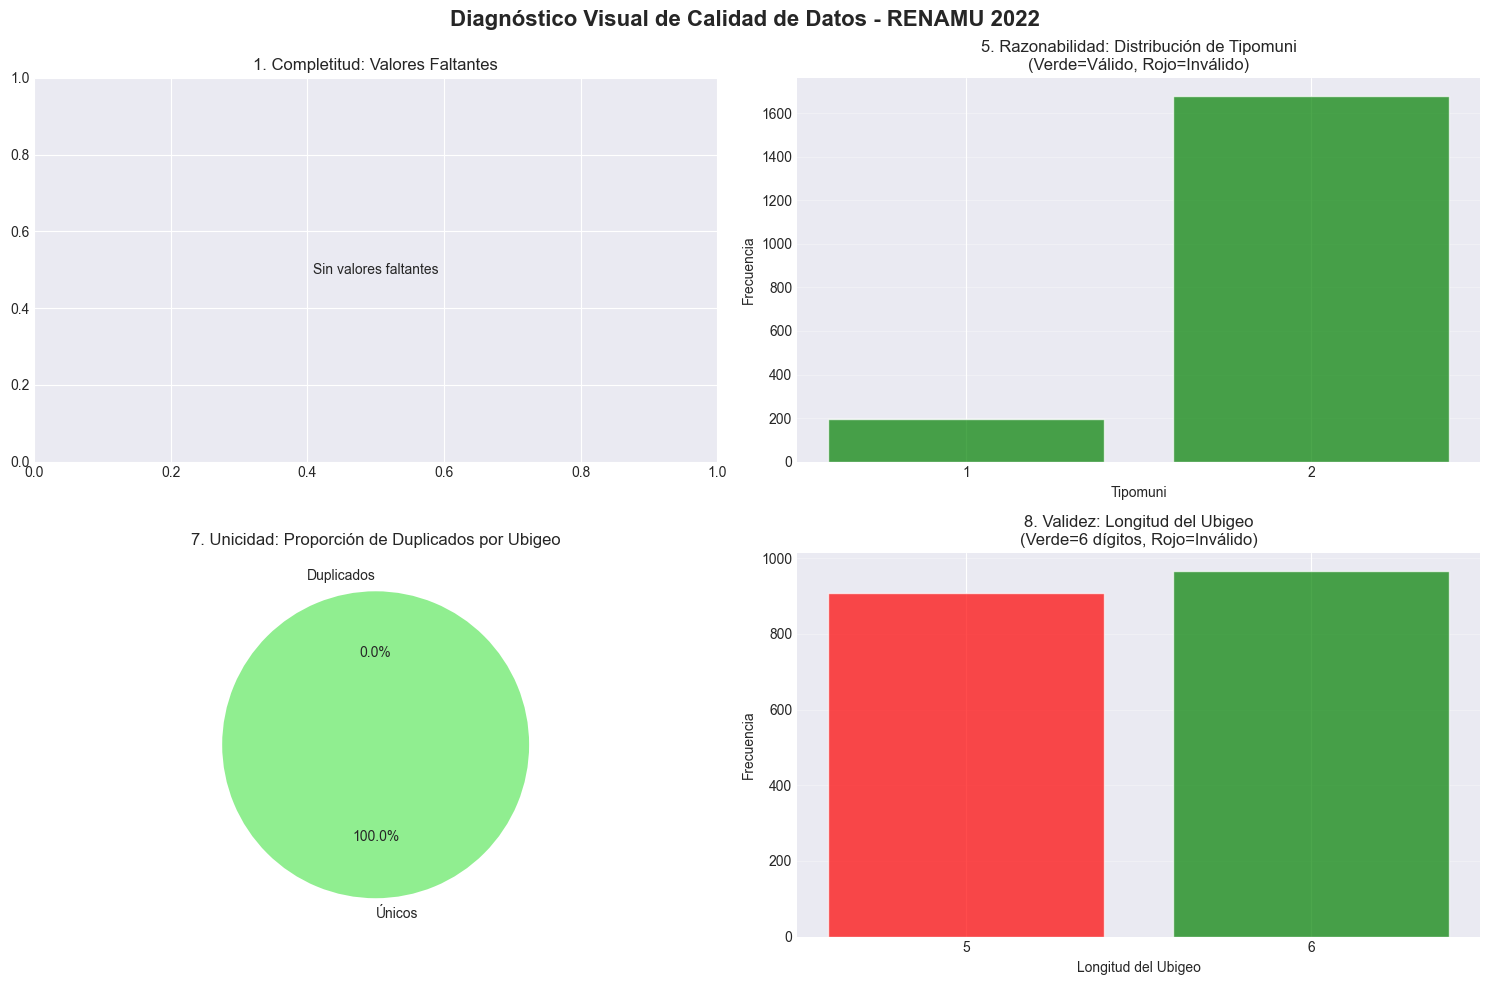

In [18]:
# Crear visualizaciones de problemas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnóstico Visual de Calidad de Datos - RENAMU 2022', fontsize=16, fontweight='bold')

# 1. Valores faltantes
if len(missing_df) > 0:
    axes[0, 0].barh(missing_df.head(10).index, missing_df.head(10)['Valores Faltantes'], color='coral')
    axes[0, 0].set_xlabel('Cantidad')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes (Top 10)')
    axes[0, 0].grid(axis='x', alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')

# 2. Distribución de Tipomuni
tipomuni_counts = df['Tipomuni'].value_counts().sort_index()
colores_tipo = ['green' if t in [1,2,3,4,5] else 'red' for t in tipomuni_counts.index]
axes[0, 1].bar(tipomuni_counts.index.astype(str), tipomuni_counts.values,
               color=colores_tipo, alpha=0.7, edgecolor='white')
axes[0, 1].set_xlabel('Tipomuni')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('5. Razonabilidad: Distribución de Tipomuni\n(Verde=Válido, Rojo=Inválido)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Duplicados por Ubigeo
duplicados_summary = pd.Series({
    'Únicos': len(df) - len(duplicados_parciales),
    'Duplicados': len(duplicados_parciales)
})
axes[1, 0].pie(duplicados_summary, labels=duplicados_summary.index, autopct='%1.1f%%',
               colors=['lightgreen', 'salmon'], startangle=90)
axes[1, 0].set_title('7. Unicidad: Proporción de Duplicados por Ubigeo')

# 4. Validez - Longitud del Ubigeo
ubigeo_len = df['Ubigeo'].astype(str).str.len().value_counts().sort_index()
colores_ubigeo = ['green' if l == 6 else 'red' for l in ubigeo_len.index]
axes[1, 1].bar(ubigeo_len.index.astype(str), ubigeo_len.values,
               color=colores_ubigeo, alpha=0.7, edgecolor='white')
axes[1, 1].set_xlabel('Longitud del Ubigeo')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('8. Validez: Longitud del Ubigeo\n(Verde=6 dígitos, Rojo=Inválido)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de las Visualizaciones

**Gráfico 1 — Completitud:**
- Muestra las columnas del RENAMU con mayor cantidad de valores faltantes
- Columnas con muchos nulos pueden afectar el JOIN con SIAF y SISMEPRE

**Gráfico 2 — Razonabilidad:**
- La distribución de Tipomuni muestra los tipos de municipalidad presentes
- Valores fuera del rango 1-5 son inválidos según el catálogo del INEI

**Gráfico 3 — Unicidad:**
- Cada Ubigeo debería aparecer una sola vez en el RENAMU
- Duplicados por Ubigeo generarían conteos incorrectos al cruzar con SIAF

**Gráfico 4 — Validez:**
- El Ubigeo debe tener exactamente 6 dígitos para el JOIN con SIAF y SISMEPRE
- Ubigeos con longitud diferente a 6 rompen la integridad referencial

---

# SOLUCIÓN NIVEL SIMPLE - RENAMU 2022

## Objetivo
Aplicar técnicas básicas de limpieza sobre el dataset RENAMU 2022
de municipalidades peruanas:
- Eliminar registros con valores nulos en columnas clave
- Eliminar duplicados exactos y por Ubigeo
- Filtrar Ubigeos con formato inválido y Tipomuni fuera de rango

### Limitaciones de este enfoque:
- Pérdida significativa de datos
- No trata problemas sutiles
- No aprovecha información recuperable

In [19]:
# Crear copia para solución simple
df_simple = df.copy()

print(f"Registros iniciales: {len(df_simple)}")
print("\nPASOS DE LIMPIEZA:\n")

# Paso 1: Eliminar filas con valores nulos en columnas clave
antes_nulos = len(df_simple)
df_simple = df_simple.dropna(subset=['Ubigeo', 'Departamento', 'Provincia', 'Distrito'])
print(f"1. Eliminación de nulos en columnas clave: {antes_nulos - len(df_simple)} registros eliminados")

# Paso 2: Eliminar duplicados exactos
antes_dup = len(df_simple)
df_simple = df_simple.drop_duplicates(keep='first')
print(f"2. Eliminación de duplicados exactos: {antes_dup - len(df_simple)} registros eliminados")

# Paso 3: Eliminar duplicados por Ubigeo
antes_ubigeo = len(df_simple)
df_simple = df_simple.drop_duplicates(subset=['Ubigeo'], keep='first')
print(f"3. Eliminación de duplicados por Ubigeo: {antes_ubigeo - len(df_simple)} registros eliminados")

# Paso 4: Filtrar Ubigeo con formato inválido
antes_formato = len(df_simple)
df_simple = df_simple[df_simple['Ubigeo'].astype(str).str.match(r'^\d{6}$')]
print(f"4. Filtrado de Ubigeo con formato inválido: {antes_formato - len(df_simple)} registros eliminados")

# Paso 5: Filtrar Tipomuni fuera de rango
antes_tipo = len(df_simple)
df_simple = df_simple[df_simple['Tipomuni'].isin([1, 2, 3, 4, 5])]
print(f"5. Filtrado de Tipomuni inválido: {antes_tipo - len(df_simple)} registros eliminados")

# Paso 6: Estandarizar nombres geográficos
df_simple['Departamento'] = df_simple['Departamento'].str.upper().str.strip()
df_simple['Provincia']    = df_simple['Provincia'].str.upper().str.strip()
df_simple['Distrito']     = df_simple['Distrito'].str.upper().str.strip()
print(f"6. Estandarización de nombres geográficos: Aplicada")

print(f"\n- Registros finales: {len(df_simple)}")
print(f"- Pérdida total: {len(df) - len(df_simple)} registros ({((len(df) - len(df_simple))/len(df)*100):.1f}%)")

Registros iniciales: 1874

PASOS DE LIMPIEZA:

1. Eliminación de nulos en columnas clave: 0 registros eliminados
2. Eliminación de duplicados exactos: 0 registros eliminados
3. Eliminación de duplicados por Ubigeo: 0 registros eliminados
4. Filtrado de Ubigeo con formato inválido: 908 registros eliminados
5. Filtrado de Tipomuni inválido: 0 registros eliminados
6. Estandarización de nombres geográficos: Aplicada

- Registros finales: 966
- Pérdida total: 908 registros (48.5%)


In [20]:
# Verificación post-limpieza
print("\nVERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)\n")
print(f"- Valores nulos en columnas clave : {df_simple[['Ubigeo','Departamento','Provincia','Distrito']].isnull().sum().sum()}")
print(f"- Duplicados por Ubigeo           : {df_simple.duplicated(subset=['Ubigeo']).sum()}")
print(f"- Ubigeo con formato inválido     : {len(df_simple[~df_simple['Ubigeo'].astype(str).str.match(r'^\d{6}$')])}")
print(f"- Tipomuni fuera de rango         : {len(df_simple[~df_simple['Tipomuni'].isin([1,2,3,4,5])])}")


VERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)

- Valores nulos en columnas clave : 0
- Duplicados por Ubigeo           : 0
- Ubigeo con formato inválido     : 0
- Tipomuni fuera de rango         : 0


In [24]:
# Convertir columnas con tipos mixtos a string para compatibilidad con Parquet
for col in df_simple.columns:
    if df_simple[col].dtype == 'object':
        df_simple[col] = df_simple[col].astype(str)

df_simple.to_parquet("renamu_silver_simple.parquet", index=False)
print(f"✅ Archivo guardado: renamu_silver_simple.parquet")
print(f"   Registros: {len(df_simple):,}")
print(f"   Columnas : {len(df_simple.columns)}")

✅ Archivo guardado: renamu_silver_simple.parquet
   Registros: 966
   Columnas : 1369


### Conclusiones de la Solución Simple

**Ventajas:**
- Fácil de implementar
- Elimina errores evidentes en Ubigeo y Tipomuni
- Garantiza que cada municipalidad aparezca una sola vez

**Desventajas:**
- Pérdida significativa de datos
- No recupera Ubigeos reconstruibles desde ccdd+ccpp+ccdi
- No trata inconsistencias entre campos geográficos
- Puede eliminar municipalidades válidas con nulos menores